# Q-learning multi-goal trên grid map 8 hướng

Notebook này cài đặt:

- Grid map 2D với vật cản
- Robot đi **8 hướng**
- **Multi-goal Q-learning**
- Có thể chọn **1 goal bắt buộc phải thăm cuối cùng**
- Có vẽ đường đi kết quả

Bạn chỉ cần sửa các biến:
- `grid`
- `start`
- `goals`
- `final_goal_idx`


In [122]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt
from collections import defaultdict

## 1) Khai báo map, start, goals

Quy ước:
- `0` = ô trống
- `1` = vật cản

`final_goal_idx` là chỉ số goal phải đi **cuối cùng**.


In [123]:
# =========================
# CẤU HÌNH BÀI TOÁN
# =========================

# Ví dụ map 20x20.
# Bạn thay trực tiếp bằng map của bạn.
grid20 = np.array([
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,1,1,1,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0],
    [0,0,1,0,1,0,0,1,1,1,0,0,0,0,0,0,1,1,1,0],
    [0,0,1,0,1,0,0,1,0,1,0,0,1,1,1,0,0,0,0,0],
    [0,0,1,0,0,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0],
    [0,0,1,1,1,1,0,1,0,1,0,1,1,0,1,0,0,1,0,0],
    [0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0],
    [0,1,1,1,1,0,0,1,1,1,0,1,0,1,1,1,0,1,0,0],
    [0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,1,0,0],
    [0,1,1,0,1,0,1,1,0,1,0,1,1,1,0,1,0,1,0,0],
    [0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0],
    [0,1,1,1,1,1,1,1,0,1,1,1,0,1,1,1,0,1,0,0],
    [0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0],
    [0,1,1,1,1,1,0,1,1,1,0,1,1,1,0,1,1,1,1,0],
    [0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0],
    [0,1,1,1,0,1,1,1,0,1,1,1,0,1,1,1,1,1,0,0],
    [0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0],
    [0,1,0,1,1,1,0,1,1,1,0,1,1,1,1,1,0,1,0,0],
    [0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0],
    [0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0],
], dtype=np.int8)

grid30 = np.array([
 [0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,1,1,1,1,0,0,0,0,0,0,0],
 [0,0,0,0,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
 [0,0,1,1,1,1,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
 [0,0,1,1,1,1,0,0,1,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,1,0,0,0,0],
 [0,0,1,1,1,1,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0],
 [1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
 [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1],
 [1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1],
 [1,1,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1],
 [1,1,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0],
 [0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0],
 [0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0],
 [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,0,1,0,0,0,0,0,0],
 [0,0,0,0,0,1,1,1,0,0,1,1,1,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0,1,0],
 [0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
 [0,0,0,0,0,1,1,1,0,0,0,1,0,0,1,1,1,1,1,0,0,1,0,0,0,0,0,0,0,0],
 [0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,1],
 [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0],
 [0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0],
 [1,0,0,0,1,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1],
 [0,0,1,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0],
 [0,0,0,0,0,0,0,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
 [0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
 [0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0],
 [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
 [0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1],
 [0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,1,1,1],
 [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,1,1],
 [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,1,1,1],
 [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1,1,0,0,0,0,0,0,0],
], dtype=np.int8)

grid = grid30  # thay bằng map của bạn

ROWS, COLS = grid.shape

start = (0, 0)
#goals = [(4, 5), (4, 15), (16, 4), (16, 15)]
goals = [(4, 6), (4, 15), (16, 4), (12, 14), (20, 20), (20, 14), (23, 17), (17, 15), (29, 29)]


# Goal phải thăm cuối cùng.
# Ví dụ 3 nghĩa là goals[3] phải là goal cuối.
final_goal_idx = len(goals) - 1

assert 0 <= final_goal_idx < len(goals)

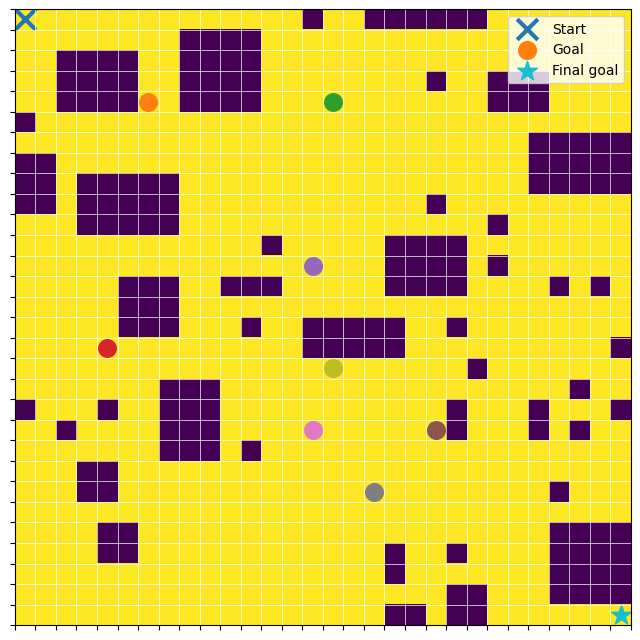

In [124]:
plt.figure(figsize=(8, 8))
plt.imshow(grid, cmap="viridis_r")

rows, cols = grid.shape
plt.xticks(np.arange(-0.5, cols, 1), [])
plt.yticks(np.arange(-0.5, rows, 1), [])
plt.grid(color="white", linewidth=0.5)

# Start
plt.scatter(start[1], start[0], marker='x', s=220, linewidths=3, label='Start')

# Goals
for i, (r, c) in enumerate(goals):
    if i == final_goal_idx:
        plt.scatter(c, r, s=220, marker='*', label='Final goal')
    else:
        plt.scatter(c, r, s=160, marker='o', label='Goal' if i == 0 else None)

#plt.title(f"Path length = {path_length(path):.2f}, steps = {len(path)-1}")
plt.legend()
# plt.gca().invert_yaxis() # Nếu bạn muốn trục y tăng xuống dưới, bỏ comment dòng này.
plt.show()

## 2) Action space 8 hướng

- 4 hướng thẳng
- 4 hướng chéo

Chi phí:
- thẳng = `1`
- chéo = `sqrt(2)`


In [125]:
ACTIONS = [
    (-1,  0),  # 0: up
    ( 1,  0),  # 1: down
    ( 0, -1),  # 2: left
    ( 0,  1),  # 3: right
    (-1, -1),  # 4: up-left
    (-1,  1),  # 5: up-right
    ( 1, -1),  # 6: down-left
    ( 1,  1),  # 7: down-right
]

ACTION_COST = [1.0, 1.0, 1.0, 1.0, math.sqrt(2), math.sqrt(2), math.sqrt(2), math.sqrt(2)]

## 3) Hàm hỗ trợ

State được mã hóa là:

`(row, col, visited_mask)`

Trong đó:
- `visited_mask` lưu các goal đã thăm
- goal cuối chỉ được đánh dấu khi các goal còn lại đã hoàn tất


In [126]:
def in_bounds(r, c):
    return 0 <= r < ROWS and 0 <= c < COLS

def is_free(r, c):
    return in_bounds(r, c) and grid[r, c] == 0

def goal_to_bit(goal_idx):
    return 1 << goal_idx

def all_goals_mask():
    return (1 << len(goals)) - 1

def non_final_goals_mask():
    return all_goals_mask() ^ goal_to_bit(final_goal_idx)

def state_key(pos, visited_mask):
    return (pos[0], pos[1], visited_mask)

def update_visited_mask(pos, visited_mask):
    """
    Nếu đi vào goal thường -> đánh dấu ngay.
    Nếu đi vào goal cuối -> chỉ đánh dấu khi mọi goal khác đã xong.
    """
    for i, g in enumerate(goals):
        if pos == g:
            if i == final_goal_idx:
                if (visited_mask & non_final_goals_mask()) == non_final_goals_mask():
                    visited_mask |= goal_to_bit(i)
            else:
                visited_mask |= goal_to_bit(i)
    return visited_mask

def get_valid_next_position(r, c, action_idx):
    """
    Chặn:
    - đi ra ngoài map
    - đi vào obstacle
    - diagonal corner cutting
    """
    dr, dc = ACTIONS[action_idx]
    nr, nc = r + dr, c + dc

    if not is_free(nr, nc):
        return None

    # Không cho cắt góc khi đi chéo
    if dr != 0 and dc != 0:
        if not is_free(r + dr, c) or not is_free(r, c + dc):
            return None

    return (nr, nc)

## 4) Reward

Thiết kế theo hướng:
- mỗi bước bị phạt
- đi chéo bị phạt theo đúng độ dài
- vào goal mới được thưởng
- vào goal cuối quá sớm bị phạt thêm
- hoàn thành toàn bộ goal được thưởng lớn


In [127]:
def compute_reward(prev_pos, next_pos, visited_before, visited_after, action_idx):
    reward = -ACTION_COST[action_idx]

    # Đi vào goal cuối quá sớm
    if next_pos == goals[final_goal_idx]:
        if (visited_before & non_final_goals_mask()) != non_final_goals_mask():
            reward -= 5.0

    # Vừa chạm goal mới
    if visited_after != visited_before:
        reward += 20.0

    return reward

## 5) Huấn luyện Q-learning

In [128]:
# Q[state][action]
Q = defaultdict(lambda: np.zeros(len(ACTIONS), dtype=float))

alpha = 0.1
gamma = 0.95
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995

episodes = 5000
max_steps_per_episode = 500

episode_rewards = []

for ep in range(episodes):
    pos = start
    visited_mask = update_visited_mask(pos, 0)
    total_reward = 0.0

    for step in range(max_steps_per_episode):
        s = state_key(pos, visited_mask)

        # epsilon-greedy
        if random.random() < epsilon:
            action = random.randint(0, len(ACTIONS) - 1)
        else:
            action = int(np.argmax(Q[s]))

        next_pos = get_valid_next_position(pos[0], pos[1], action)

        # Hành động không hợp lệ
        if next_pos is None:
            reward = -10.0
            s_next = s
            Q[s][action] += alpha * (reward + gamma * np.max(Q[s_next]) - Q[s][action])
            total_reward += reward
            continue

        visited_after = update_visited_mask(next_pos, visited_mask)
        reward = compute_reward(pos, next_pos, visited_mask, visited_after, action)
        s_next = state_key(next_pos, visited_after)

        Q[s][action] += alpha * (reward + gamma * np.max(Q[s_next]) - Q[s][action])

        pos = next_pos
        visited_mask = visited_after
        total_reward += reward

        if visited_mask == all_goals_mask():
            total_reward += 50.0
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    episode_rewards.append(total_reward)

print("Training xong.")

Training xong.


## 6) Hàm lấy path sau khi học

In [129]:
def extract_path(Q, start, max_steps=500):
    pos = start
    visited_mask = update_visited_mask(pos, 0)
    path = [pos]

    for _ in range(max_steps):
        s = state_key(pos, visited_mask)
        q_values = Q[s]
        sorted_actions = np.argsort(q_values)[::-1]

        next_pos = None
        chosen_action = None
        for a in sorted_actions:
            cand = get_valid_next_position(pos[0], pos[1], int(a))
            if cand is not None:
                chosen_action = int(a)
                next_pos = cand
                break

        if next_pos is None:
            break

        pos = next_pos
        visited_mask = update_visited_mask(pos, visited_mask)
        path.append(pos)

        if visited_mask == all_goals_mask():
            break

    return path, visited_mask

def path_length(path):
    total = 0.0
    for i in range(1, len(path)):
        r1, c1 = path[i - 1]
        r2, c2 = path[i]
        dr = abs(r2 - r1)
        dc = abs(c2 - c1)
        total += math.sqrt(2) if (dr == 1 and dc == 1) else 1.0
    return total

path, final_mask = extract_path(Q, start)

def extract_goal_order(path, goals):
    seen = set()
    order = []
    for p in path:
        if p in goals and p not in seen:
            order.append(p)
            seen.add(p)
    return order

goal_order = extract_goal_order(path, goals)
goal_indices = [goals.index(g) for g in goal_order]

print("Thu tu goal:", goal_order)
print("Chi so goal:", goal_indices)

print(path)
print("Số bước:", len(path) - 1)
print("Độ dài đường đi:", round(path_length(path), 3))
print("Đã hoàn thành hết goal chưa:", final_mask == all_goals_mask())
print("Goal cuối bắt buộc:", goals[final_goal_idx])

Thu tu goal: [(4, 6), (4, 15), (12, 14), (20, 14), (17, 15), (20, 20), (23, 17), (16, 4), (29, 29)]
Chi so goal: [0, 1, 3, 5, 7, 4, 6, 2, 8]
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 5), (1, 6), (2, 7), (3, 7), (4, 6), (5, 7), (5, 8), (6, 9), (6, 10), (6, 11), (5, 12), (5, 13), (5, 14), (4, 15), (5, 15), (6, 14), (7, 14), (8, 14), (9, 14), (10, 13), (11, 13), (12, 14), (13, 14), (14, 13), (15, 13), (16, 13), (17, 13), (18, 13), (19, 14), (20, 14), (19, 14), (18, 15), (17, 15), (17, 16), (18, 17), (19, 18), (20, 19), (20, 20), (21, 19), (22, 18), (23, 17), (23, 16), (22, 15), (21, 14), (20, 13), (19, 12), (18, 11), (17, 10), (17, 9), (17, 8), (17, 7), (16, 6), (16, 5), (16, 4), (16, 5), (16, 6), (16, 7), (16, 8), (16, 9), (16, 10), (16, 11), (16, 12), (17, 13), (17, 14), (18, 15), (19, 16), (20, 17), (21, 18), (22, 19), (23, 20), (24, 21), (25, 22), (26, 22), (27, 23), (28, 24), (29, 25), (29, 26), (29, 27), (29, 28), (29, 29)]
Số bước: 84
Độ dài đường đi: 99.74
Đã hoàn thành hết goa

## 7) Vẽ kết quả

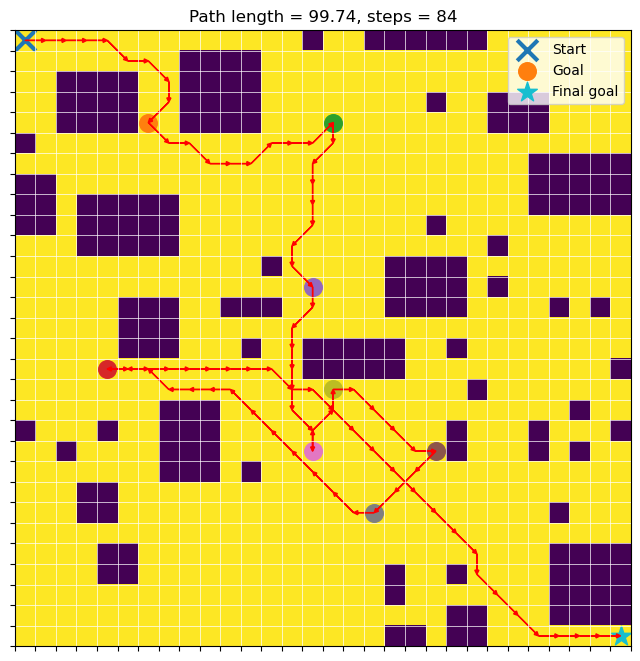

In [130]:
def plot_result(grid, start, goals, final_goal_idx, path):
    plt.figure(figsize=(8, 8))
    plt.imshow(grid, cmap="viridis_r")

    rows, cols = grid.shape
    plt.xticks(np.arange(-0.5, cols, 1), [])
    plt.yticks(np.arange(-0.5, rows, 1), [])
    plt.grid(color="white", linewidth=0.5)

    # Start
    plt.scatter(start[1], start[0], marker='x', s=220, linewidths=3, label='Start')

    # Goals
    for i, (r, c) in enumerate(goals):
        if i == final_goal_idx:
            plt.scatter(c, r, s=220, marker='*', label='Final goal')
        else:
            plt.scatter(c, r, s=160, marker='o', label='Goal' if i == 0 else None)

    # Path nối bởi các đoạn thẳng (không có mũi tên)
    # if len(path) > 1:
    #     xs = [p[1] for p in path]
    #     ys = [p[0] for p in path]
    #     plt.plot(xs, ys, linewidth=2)

    # Path (draw arrows showing movement direction)
    if len(path) > 1:
        xs = [p[1] for p in path]
        ys = [p[0] for p in path]

        for i in range(len(path) - 1):
            x0, y0 = xs[i], ys[i]
            x1, y1 = xs[i + 1], ys[i + 1]
            dx, dy = x1 - x0, y1 - y0
            plt.arrow(
                x0,
                y0,
                dx,
                dy,
                head_width=0.2,
                head_length=0.2,
                length_includes_head=True,
                fc="red",
                ec="red",
            )

    plt.title(f"Path length = {path_length(path):.2f}, steps = {len(path)-1}")
    plt.legend()
    # plt.gca().invert_yaxis()
    plt.show()

plot_result(grid, start, goals, final_goal_idx, path)

## 8) Vẽ reward theo episode

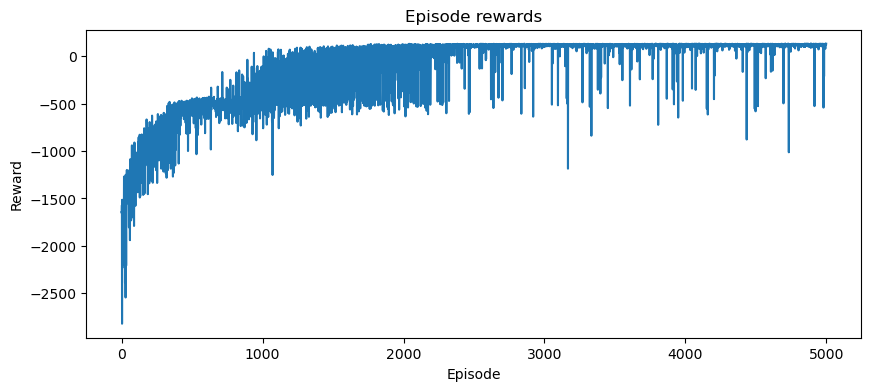

In [131]:
plt.figure(figsize=(10, 4))
plt.plot(episode_rewards)
plt.title("Episode rewards")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

## Gợi ý chỉnh cho map của bạn

Bạn thường chỉ cần sửa:

```python
grid = ...
start = ...
goals = ...
final_goal_idx = ...
```

Nếu map lớn hơn, bạn có thể tăng:
- `episodes`
- `max_steps_per_episode`

Nếu học chậm, có thể thêm reward shaping theo khoảng cách tới goal chưa thăm gần nhất.
